In [285]:
import scipy
from pathlib import Path
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations
from scipy import stats
import sys
import os
import time
import mat73

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC, LinearSVC
from sklearn.multiclass import OneVsOneClassifier
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, classification_report
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.linear_model import LogisticRegression as LogReg

from spike_generator import generate_spikes

from perceptual_straightening.modules import ELBO

In [297]:
# load sample neural responses
data_path = Path('data')
f_name = 'sim_0000_1k_trials.mat'

S = mat73.loadmat(Path(data_path) / f_name)
tuning_curves = S['S']['tuning_curves']
gain = S['S']['gain']
rate = S['S']['lambda']

mat2 = scipy.io.loadmat(Path('data') / 'bin_sizes_all.mat')
bin_sizes_all = mat2['bin_sizes_all'][0]
# ibin = 11
ibin = -3
# ibin = -7
# ibin = 10

# n_neurons = rate.shape[0]
# n_trials = rate.shape[2]

In [ ]:
# # load sample neural responses
# data_path = Path('data')
# f_name = 'sim_0000.mat'
# S = scipy.io.loadmat(Path(data_path) / f_name)['S']
# S_list = [S[0, i] for i in range(S.shape[1])]  # convert to list of structs

# # unpack data
# # rate = S_list[1]['lambda'][0, 0]
# tuning_curves = S_list[0]['tuning_curves']
# gain = S_list[0]['gain']
# rate = S_list[0]['lambda']

# mat2 = scipy.io.loadmat(Path('data') / 'bin_sizes_all.mat')
# bin_sizes_all = mat2['bin_sizes_all'][0]
# # ibin = 11
# ibin = -3
# # ibin = -7
# # ibin = 10

# # n_neurons = rate.shape[0]
# # n_trials = rate.shape[2]

In [ ]:
# # load sample neural responses
# data_path = Path('data')
# f_name = 'sim_0092.mat'
# S = scipy.io.loadmat(Path(data_path) / f_name)['S']
# S_list = [S[0, i] for i in range(S.shape[1])]  # convert to list of structs

# # unpack data
# # rate = S_list[1]['lambda'][0, 0]
# tuning_curves = S_list[3]['tuning_curves'][0, 0]
# gain = S_list[3]['gain'][0, 0]

# mat2 = scipy.io.loadmat(Path('data') / 'bin_sizes_all.mat')
# bin_sizes_all = mat2['bin_sizes_all'][0]
# # ibin = 11
# ibin = -3
# # ibin = -7
# # ibin = -8
# # ibin = 10

# # n_neurons = rate.shape[0]
# # n_trials = rate.shape[2]

In [219]:
# # mat_lambda = scipy.io.loadmat(Path('data') / 'lambda_slow-gain.mat')
# # rate = mat_lambda['lambda']
# mat_tuning = scipy.io.loadmat(Path('data') / 'tuning_slow-gain.mat')
# tuning_curves = mat_tuning['tuning_curves']
# mat_gain = scipy.io.loadmat(Path('data') / 'gain_slow-gain.mat')
# gain = mat_gain['gain']

# mat2 = scipy.io.loadmat(Path('data') / 'bin_sizes_all.mat')
# bin_sizes_all = mat2['bin_sizes_all'][0]
# # ibin = 11
# ibin = -3
# # ibin = -7

# # n_neurons = rate.shape[0]
# # n_trials = rate.shape[2]

In [220]:
# # find reasonable tuning curves
# for i in range(tuning_curves.shape[0]):
#     if np.mean(np.repeat(tuning_curves[i][np.newaxis, :], i, axis=0) * gain[:i]) > 5:
#         print(i)

In [298]:
# rate using a single neural tuning curve
n_neurons = 2
# ineuron = 29 # for sim_0000.mat
ineuron = 2
rate = np.repeat(tuning_curves[ineuron][np.newaxis, :], n_neurons, axis=0) * gain[:n_neurons]
n_trials = rate.shape[2]

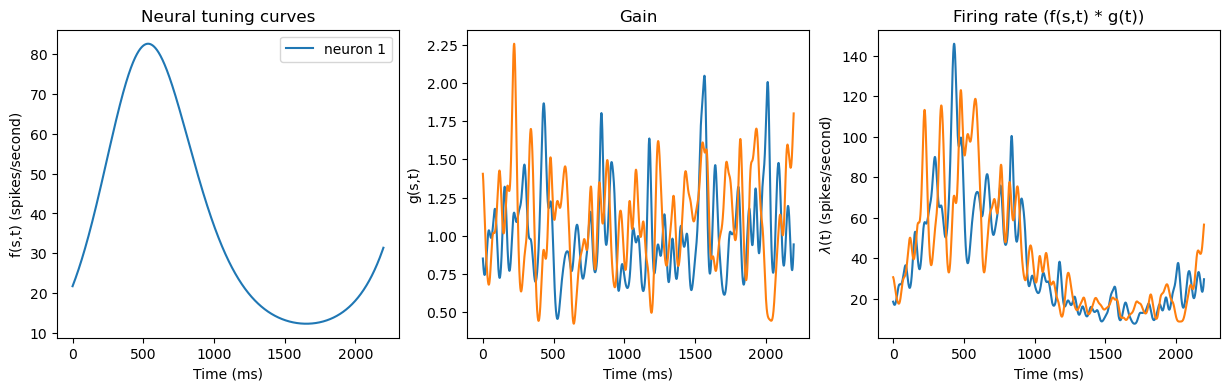

In [299]:
# pick two neurons only
# neuron_idx = [12, 14]
# neuron_idx = [12, 13, 14]
# neuron_idx = [12, 13, 14, 15]
neuron_idx = np.arange(0, n_neurons)

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

# axs[0].plot(tuning_curves[:, :, 0].T)
axs[0].plot(tuning_curves[ineuron, :, 0].T)
axs[0].set_xlabel('Time (ms)')
axs[0].set_ylabel('f(s,t) (spikes/second)')
axs[0].set_title('Neural tuning curves')
axs[0].legend(('neuron 1','neuron 2'))

# axs[1].plot(gain[:, :, 0].T)
axs[1].plot(gain[:n_neurons, :, 0].T)
axs[1].set_xlabel('Time (ms)')
axs[1].set_ylabel('g(s,t)')
axs[1].set_title('Gain')
# axs[1].legend(('neuron 1','neuron 2'))

axs[2].plot(rate[:, :, 0].T)
axs[2].set_xlabel('Time (ms)')
axs[2].set_ylabel(r'$\lambda$(t) (spikes/second)')
axs[2].set_title('Firing rate (f(s,t) * g(t))')
# axs[2].legend(('neuron 1','neuron 2'))

plt.show()

In [223]:
# simulate spikes
dt = 1e-3
# spike_train = generate_spikes(rate[neuron_idx], dt) # create population response vectors
spike_train = generate_spikes(rate, dt) # create population response vectors

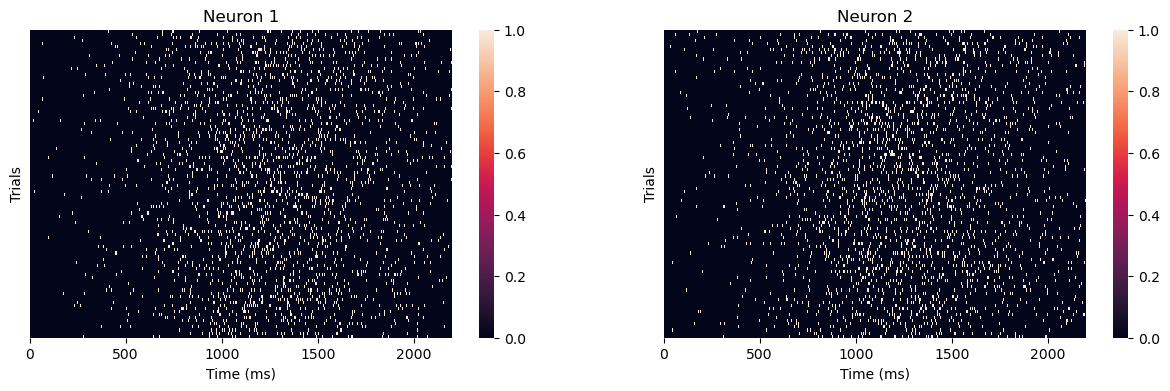

In [224]:
# plot spike trains
ticks = np.arange(0, spike_train.shape[1], 500)

fig, axs = plt.subplots(1, 2, figsize=(15, 4))

sns.heatmap(spike_train[0].T, ax=axs[0], yticklabels=False)
axs[0].set_title('Neuron 1')

sns.heatmap(spike_train[1].T, ax=axs[1], yticklabels=False)
axs[1].set_title('Neuron 2')

for i in range(2):
    axs[i].set_xlabel('Time (ms)')
    axs[i].set_ylabel('Trials')
    axs[i].set_xticks(ticks)
    axs[i].set_xticklabels(ticks)
    axs[i].tick_params(axis='x', labelrotation=0)

plt.show()

In [225]:
# create population response vectors; the number of bins determine the number of representational locations
bin_length = int(bin_sizes_all[ibin] / dt)
n_bins = int(spike_train.shape[1] // bin_length)
spike_train_reshaped = np.reshape(spike_train, (len(neuron_idx), n_bins, bin_length, n_trials)) # n_neurons x n_bins x bin_length x n_trials
mean_spike_train = np.sum(spike_train_reshaped, axis=2) # n_neurons x n_bins x n_trials
print(f'Number of bins: {n_bins}')

Number of bins: 4


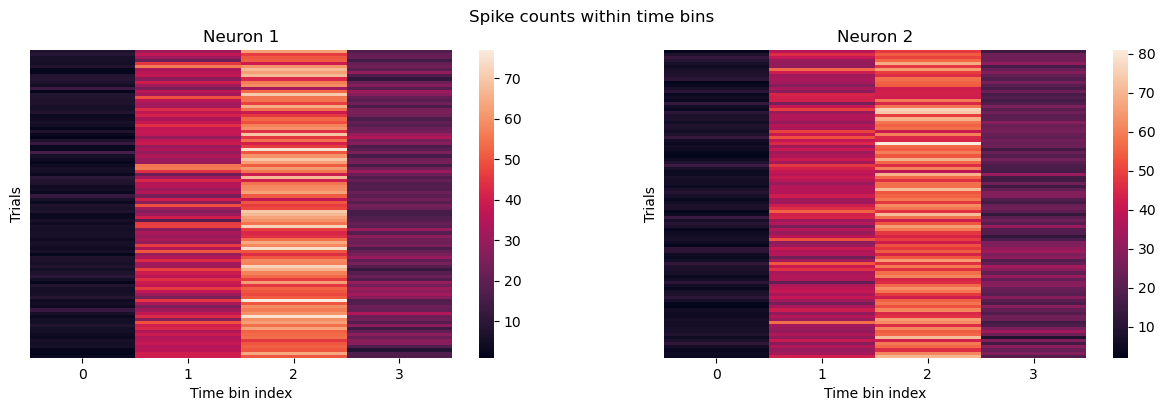

In [226]:
# plot binned spike counts
ticks = np.arange(0, spike_train.shape[1], 500)

fig, axs = plt.subplots(1, 2, figsize=(15, 4))

sns.heatmap(mean_spike_train[0].T, ax=axs[0], yticklabels=False)
axs[0].set_title('Neuron 1')

sns.heatmap(mean_spike_train[1].T, ax=axs[1], yticklabels=False)
axs[1].set_title('Neuron 2')

for i in range(2):
    axs[i].set_xlabel('Time bin index')
    axs[i].set_ylabel('Trials')
    axs[i].tick_params(axis='x', labelrotation=0)

fig.suptitle('Spike counts within time bins')
plt.show()

In [227]:
# # check if total spike counts (over time) are still the same
# fig, axs = plt.subplots(1, 2, figsize=(13, 4))

# axs[0].plot(np.sum(spike_train[0], axis=0), np.sum(mean_spike_train[0], axis=0))
# axs[1].plot(np.sum(spike_train[1], axis=0), np.sum(mean_spike_train[1], axis=0))

In [228]:
start_time = time.perf_counter()

# create data consistent with sklearn convention
X = mean_spike_train.transpose(1, 2, 0).reshape((-1, len(neuron_idx))) # n_samples x n_features
y = np.repeat(np.arange(n_bins), n_trials)

# split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# initialize the SVM classifier with One-vs-One strategy
# clf = OneVsOneClassifier(LinearSVC(random_state=42))
clf = OneVsOneClassifier(SVC(kernel='linear', random_state=42))
# clf = OneVsOneClassifier(LDA())
# clf = OneVsOneClassifier(LogReg())
# clf = SVC(decision_function_shape='ovo', kernel='linear')
# clf = SVC(decision_function_shape='ovo', kernel='rbf')
clf.fit(X_train, y_train)

end_time = time.perf_counter()

# predict and evaluate the One-vs-One model
print("One-vs-One accuracy:", clf.score(X_test, y_test))
print("One-vs-One accuracy (manually computed):", np.sum(clf.predict(X_test) == y_test) / len(y_test))

duration = end_time - start_time
print(f"Executed in {duration:.6f} seconds")


One-vs-One accuracy: 0.975
One-vs-One accuracy (manually computed): 0.975
Executed in 0.015130 seconds


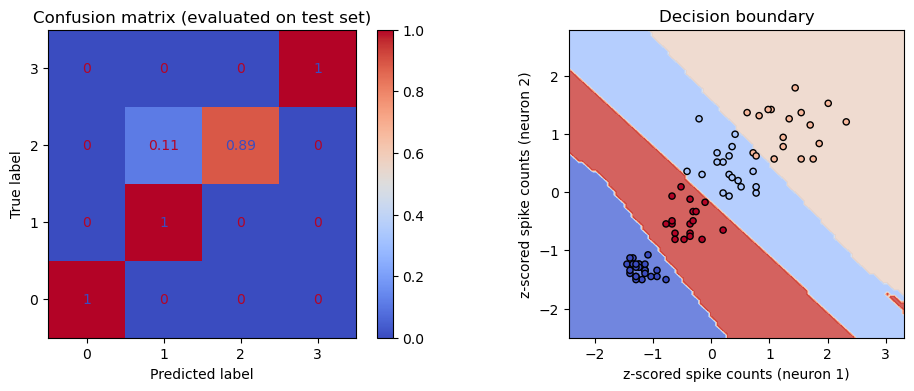

In [229]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

disp1 = ConfusionMatrixDisplay.from_estimator(
    clf, X_test, y_test, normalize='true', cmap='coolwarm', ax=axs[0]
)
disp1.im_.set_clim(0, 1)
axs[0].set_title('Confusion matrix (evaluated on test set)')
axs[0].invert_yaxis()

if len(neuron_idx) == 2:
    disp1 = DecisionBoundaryDisplay.from_estimator(
            clf, 
            X_test, 
            response_method="predict", 
            cmap=plt.cm.coolwarm, 
            alpha=0.8, 
            ax=axs[1], 
            xlabel='z-scored spike counts (neuron 1)', 
            ylabel='z-scored spike counts (neuron 2)',
        )
    axs[1].scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=plt.cm.coolwarm, s=20, edgecolors="k")
    # axs[1].set_xticks(())
    # axs[1].set_yticks(())
    axs[1].set_aspect('equal')
    axs[1].set_title('Decision boundary')

plt.show()

In [230]:
# this list perfectly aligns with the clf.estimators_
class_pairs = list(combinations(range(len(clf.classes_)), 2))
y_pred = clf.predict(X_test) # ensemble (final) classification

# compute discriminability
discrim_mat = np.zeros((n_bins, n_bins))
count_mat = np.zeros((n_bins, n_bins))

for idx, (i, j) in enumerate(class_pairs):
    class_i = clf.classes_[i]
    class_j = clf.classes_[j]
    
    # # restrict myself to only those data points that belong to the correct ground truth class
    label_inds = np.where(y_test == class_i | (y_test == class_j))
    discrim_mat[i, j] = discrim_mat[j, i] = clf.score(X_test[label_inds], y_test[label_inds])
    count_mat[i, j] = count_mat[j, i] = len(y_test[label_inds])
    # discrim_mat[i, j] = discrim_mat[j, i] = clf.score(X_test, y_test)
    # count_mat[i, j] = count_mat[j, i] = len(y_test)
        
np.fill_diagonal(discrim_mat, np.nan)

Mean discriminability: 0.9907407407407408


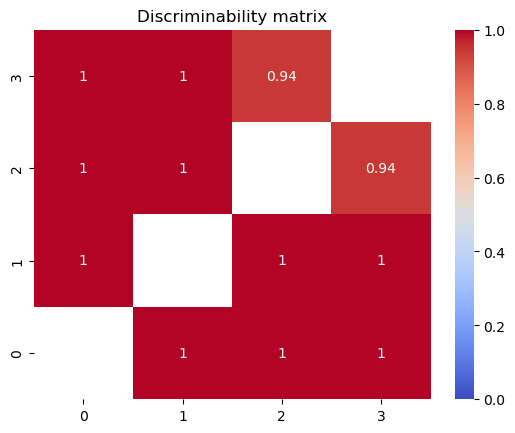

In [231]:
# plot discriminability matrix
sns.heatmap(discrim_mat, vmin=0, vmax=1, cmap='coolwarm', annot=True)
plt.title('Discriminability matrix')
plt.gca().invert_yaxis()
print(f'Mean discriminability: {np.nanmean(discrim_mat)}')

One-vs-One accuracy: 0.940625
One-vs-One accuracy (manually computed): 0.940625


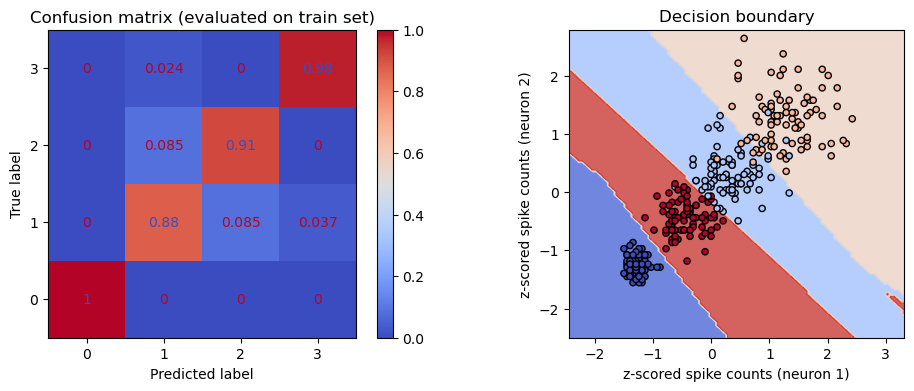

In [232]:
# evaluate on training set
print("One-vs-One accuracy:", clf.score(X_train, y_train))
print("One-vs-One accuracy (manually computed):", np.sum(clf.predict(X_train) == y_train) / len(y_train))

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

disp1 = ConfusionMatrixDisplay.from_estimator(
    clf, X_train, y_train, normalize='true', cmap='coolwarm', ax=axs[0]
)
disp1.im_.set_clim(0, 1)
axs[0].set_title('Confusion matrix (evaluated on train set)')
axs[0].invert_yaxis()

if len(neuron_idx) == 2:
    disp1 = DecisionBoundaryDisplay.from_estimator(
            clf, 
            X_test, 
            response_method="predict", 
            cmap=plt.cm.coolwarm, 
            alpha=0.8, 
            ax=axs[1], 
            xlabel='z-scored spike counts (neuron 1)', 
            ylabel='z-scored spike counts (neuron 2)',
        )
    axs[1].scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=plt.cm.coolwarm, s=20, edgecolors="k")
    # axs[1].set_xticks(())
    # axs[1].set_yticks(())
    axs[1].set_aspect('equal')
    axs[1].set_title('Decision boundary')

plt.show()

In [233]:
# # compute curvature
# n_corr_obs = discrim_mat * count_mat
# n_total_obs = count_mat

# n_dim = n_bins - 1
# n_iterations = 40000
# n_starts = 10

# elbo = ELBO(n_dim, n_corr_obs, n_total_obs, n_starts=n_starts, n_iterations=n_iterations, verbose=True)
# c_est, p, elbo_loss_hist, kl_loss_hist, ll_loss_hist, c_prior_hist, d_prior_hist, l_prior_hist, c_post_hist, d_post_hist, l_post_hist = elbo.optimize_ELBO_SGD()

In [234]:
# fig, axs = plt.subplots(1, 3, figsize=(20, 6))

# axs[0].plot(c_prior_hist, label=r'$\mu_c$')
# axs[0].set_ylabel(r'$\mu_{c}$ (degrees)')

# axs[1].plot(d_prior_hist, label=r'$\mu_d$')
# axs[1].set_ylabel(r'$\mu_{d}$')

# axs[2].plot(l_prior_hist, label=r'$\mu_{\lambda}$')
# axs[2].set_ylabel(r'$\mu_{\lambda}$')

# for i in range(3):
#     axs[i].legend()
#     axs[i].set_xlabel('Iteration')

# fig.suptitle('Parameter learning over iterations (prior)')
# plt.show()

In [235]:
# import torch
# c_est = torch.rad2deg(torch.mean(c_est)).detach().numpy()

# np.save(Path('data') / 'results' / f'{f_name.split('.')[0]}_results', c_est)

In [236]:
# b = np.load(Path('data') / 'results' / f'{f_name.split('.')[0]}_discrim.npy')
# print(b)